# Exploratory Data Analysis (EDA)

This notebook explores the hourly electricity demand data for the PJM East region.
The goal is to understand the structure, temporal patterns, seasonality, and potential
issues in the data before moving to feature engineering and modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")

## 1. Load raw data

In [2]:
DATA_PATH = "../data/raw/electricity_demand_pjm_east_hourly.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


## 2. Initial data inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [4]:
df.columns = ["timestamp", "load_mw"]
df.head()

,timestamp,load_mw
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


## 3. Time index validation and cleaning

In [5]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicated timestamps:", df["timestamp"].duplicated().sum())

Missing values:
timestamp    0
load_mw      0
dtype: int64

Duplicated timestamps: 4


Energy consumption datasets often contain duplicated timestamps due to daylight saving time transitions.
To ensure a regular hourly time series, duplicated timestamps are aggregated using the mean value before enforcing an hourly frequency.

In [6]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp")
df = df.sort_index()

df.head()

,load_mw
timestamp,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [7]:
# Aggregate duplicate timestamps (e.g. due to daylight saving time)
df_clean = df.groupby(df.index).mean()

# Enforce hourly frequency
df_clean = df_clean.asfreq("H")

df_clean.head()

,load_mw
timestamp,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


## 4. Exploratory analysis

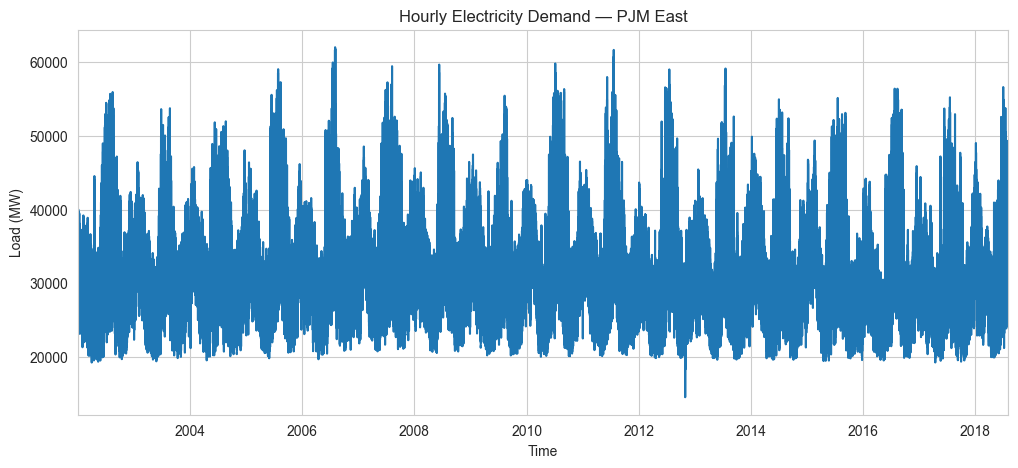

In [8]:
df_clean["load_mw"].plot()
plt.title("Hourly Electricity Demand — PJM East")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.show()

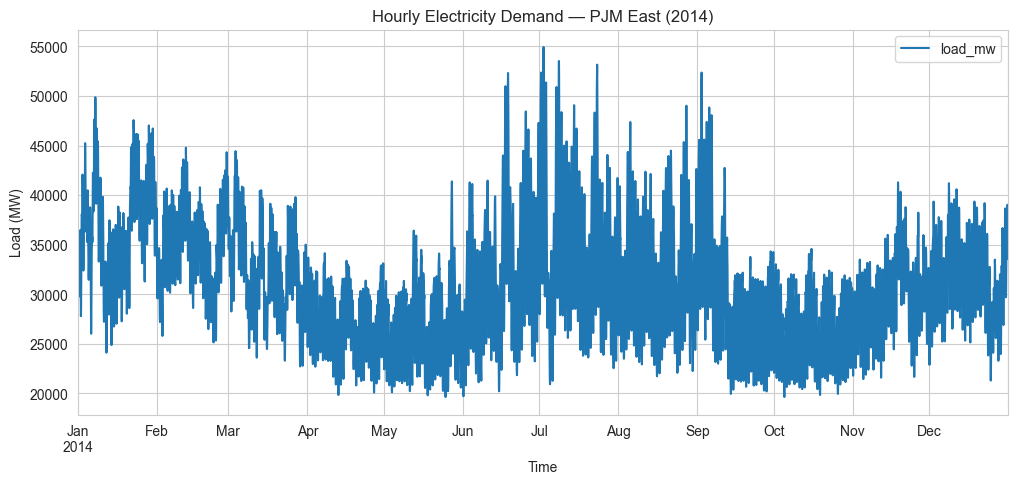

In [9]:
df_clean.loc["2014"].plot()
plt.title("Hourly Electricity Demand — PJM East (2014)")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.show()

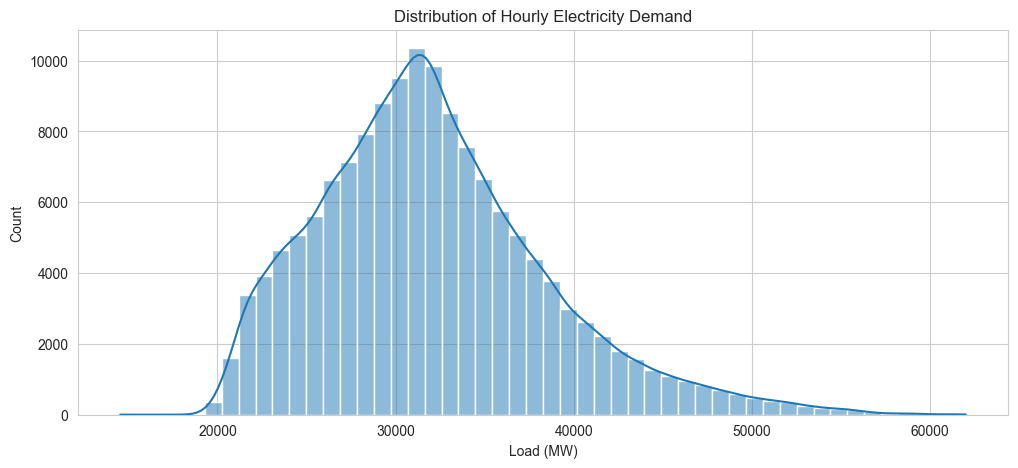

In [10]:
sns.histplot(df_clean["load_mw"], bins=50, kde=True)
plt.title("Distribution of Hourly Electricity Demand")
plt.xlabel("Load (MW)")
plt.show()

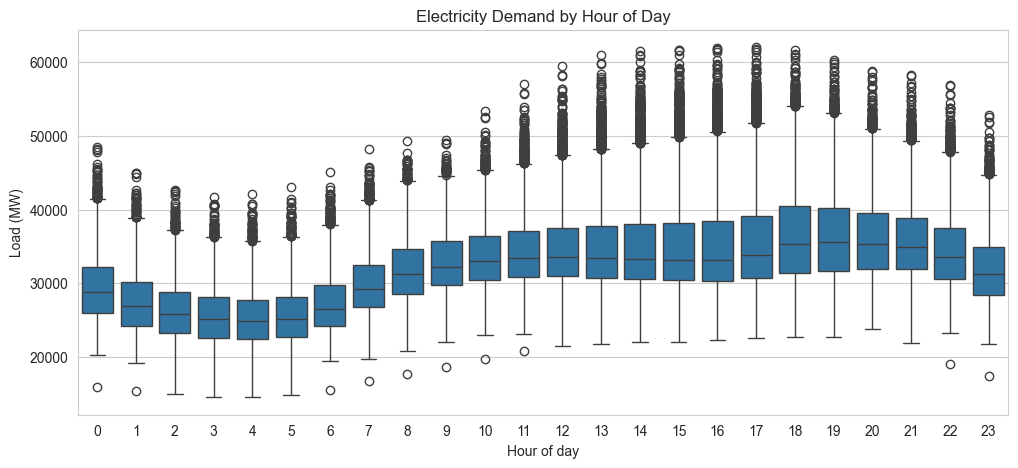

In [11]:
df_clean["hour"] = df_clean.index.hour

sns.boxplot(x="hour", y="load_mw", data=df_clean)
plt.title("Electricity Demand by Hour of Day")
plt.xlabel("Hour of day")
plt.ylabel("Load (MW)")
plt.show()

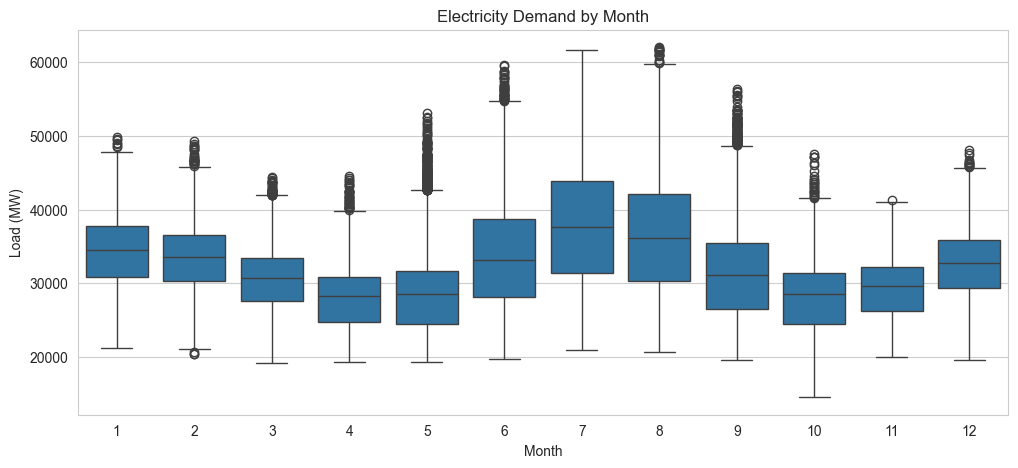

In [12]:
df_clean["month"] = df_clean.index.month

sns.boxplot(x="month", y="load_mw", data=df_clean)
plt.title("Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Load (MW)")
plt.show()

## 5. Save cleaned hourly dataset

In [13]:
df_processed = df_clean[["load_mw"]].copy()

output_path = "../data/processed/electricity_hourly_clean.csv"
df_processed.to_csv(output_path)

print(f"Saved clean dataset to {output_path}")

df_processed.head()

Saved clean dataset to ../data/processed/electricity_hourly_clean.csv


,load_mw
timestamp,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


## Key observations

- The time series shows strong daily and seasonal patterns.
- Electricity demand varies significantly by hour of day and month.
- No major missing values or structural issues are observed.
- The dataset is well-suited for supervised time series forecasting.

Next steps will focus on feature engineering and baseline forecasting models.
